# 7. 연도별 베스트셀러 트렌드 분석

분석 질문: 2009년부터 2022년까지 베스트셀러 도서의 장르, 평점, 리뷰 수, 가격은 어떻게 변화했는가?

분석 내용:
- 연도별 평균 평점 변화
- 연도별 평균 리뷰 수 변화
- 연도별 평균 가격 변화
- 연도별 Fiction / Non Fiction 비율 변화

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.unicode_minus"] = False
plt.rc("font", family="Malgun Gothic")

## 1. 데이터 불러오기

In [ ]:
trend_df = pd.read_csv("../data/processed/amazon_clean.csv", encoding="utf-8-sig")

trend_df.head()

,title_key,author_key,year,title,author,amazon_rating,amazon_reviews,price,genre,title_length,title_word_count,has_colon,has_number,review_log,review_level,rating_level
0,10day green smoothie cleanse,jj smith,2016,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350.0,8.0,Non Fiction,29,4,0,1,9.761405,middle,high
1,112263 a novel,stephen king,2011,11/22/63: A Novel,Stephen King,4.6,2052.0,22.0,Fiction,17,3,1,1,7.627057,low,high
2,12 rules for life an antidote to chaos,jordan b peterson,2018,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979.0,15.0,Non Fiction,39,8,1,1,9.851141,middle,high
3,1984,george orwell,2021,1984,George Orwell,4.7,60381.0,7.0,Fiction,4,1,0,1,11.008446,high,high
4,1984 signet classics,george orwell,2017,1984 (Signet Classics),George Orwell,4.7,21424.0,6.0,Fiction,22,3,0,1,9.972314,high,high


In [ ]:
print(trend_df.shape)
print(trend_df[["year", "amazon_rating", "amazon_reviews", "price", "genre"]].isna().sum())
trend_df[["year", "amazon_rating", "amazon_reviews", "price", "genre"]].describe(include="all")

(697, 16)
year              0
amazon_rating     0
amazon_reviews    0
price             0
genre             0
dtype: int64


,year,amazon_rating,amazon_reviews,price,genre
count,697.000000,697.000000,697.000000,697.000000,697
unique,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,Non Fiction
freq,NaN,NaN,NaN,NaN,387
mean,2015.510760,4.639311,19203.172166,12.708752,NaN
std,4.038281,0.218875,23630.421823,9.932124,NaN
min,2009.000000,3.300000,37.000000,0.000000,NaN
25%,2012.000000,4.500000,4910.000000,7.000000,NaN
50%,2016.000000,4.700000,10191.000000,11.000000,NaN
75%,2019.000000,4.800000,23308.000000,15.000000,NaN


## 2. 연도별 평균 평점, 리뷰 수, 가격

In [ ]:
yearly_trend = (
    trend_df
    .groupby("year")
    .agg(
        평균_평점=("amazon_rating", "mean"),
        평균_리뷰수=("amazon_reviews", "mean"),
        평균_가격=("price", "mean"),
        도서수=("title", "count")
    )
    .reset_index()
)

yearly_trend

,year,평균_평점,평균_리뷰수,평균_가격,도서수
0,2009,4.584000,4710.120000,15.400000,50
1,2010,4.558000,5479.620000,13.480000,50
2,2011,4.553061,7983.061224,15.255102,49
3,2012,4.532000,13090.920000,15.300000,50
4,2013,4.554000,13098.140000,14.600000,50
5,2014,4.616667,14850.875000,14.739583,48
6,2015,4.648000,14233.380000,10.420000,50
7,2016,4.678000,14196.000000,13.180000,50
8,2017,4.660000,12888.400000,11.380000,50
9,2018,4.668000,13930.420000,10.520000,50


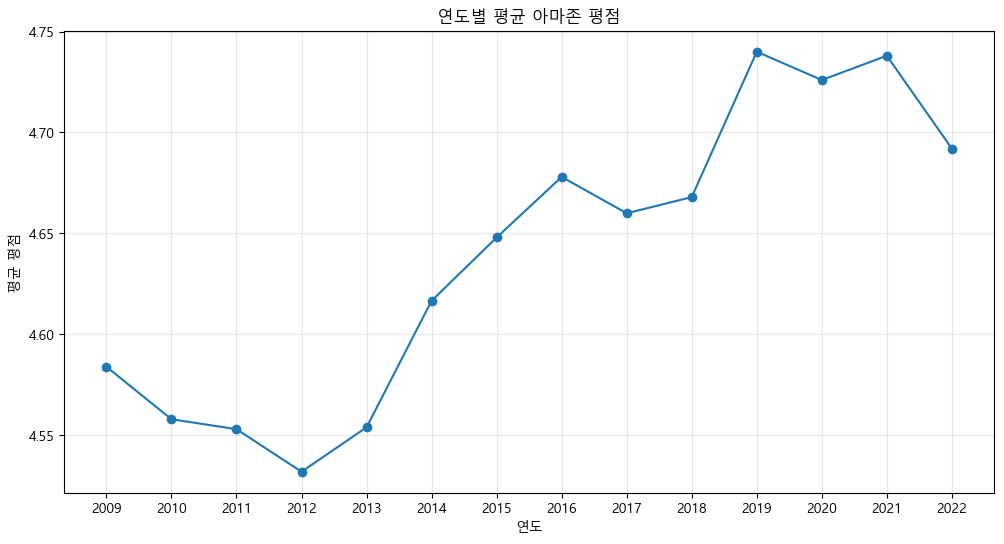

In [ ]:
plt.plot(yearly_trend["year"], yearly_trend["평균_평점"], marker="o")
plt.title("연도별 평균 아마존 평점")
plt.xlabel("연도")
plt.ylabel("평균 평점")
plt.xticks(yearly_trend["year"])
plt.grid(True, alpha=0.3)
plt.show()

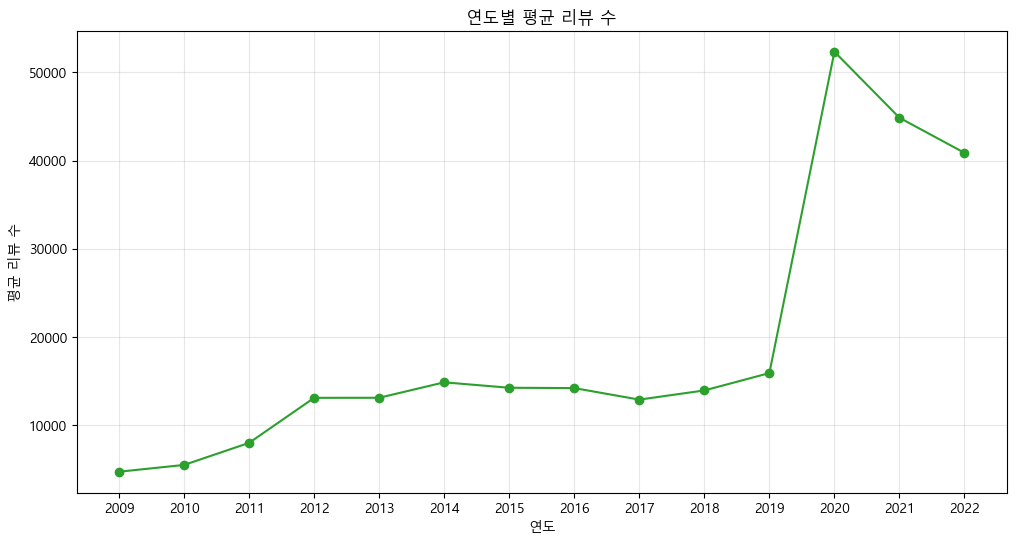

In [ ]:
plt.plot(yearly_trend["year"], yearly_trend["평균_리뷰수"], marker="o", color="tab:green")
plt.title("연도별 평균 리뷰 수")
plt.xlabel("연도")
plt.ylabel("평균 리뷰 수")
plt.xticks(yearly_trend["year"])
plt.grid(True, alpha=0.3)
plt.show()

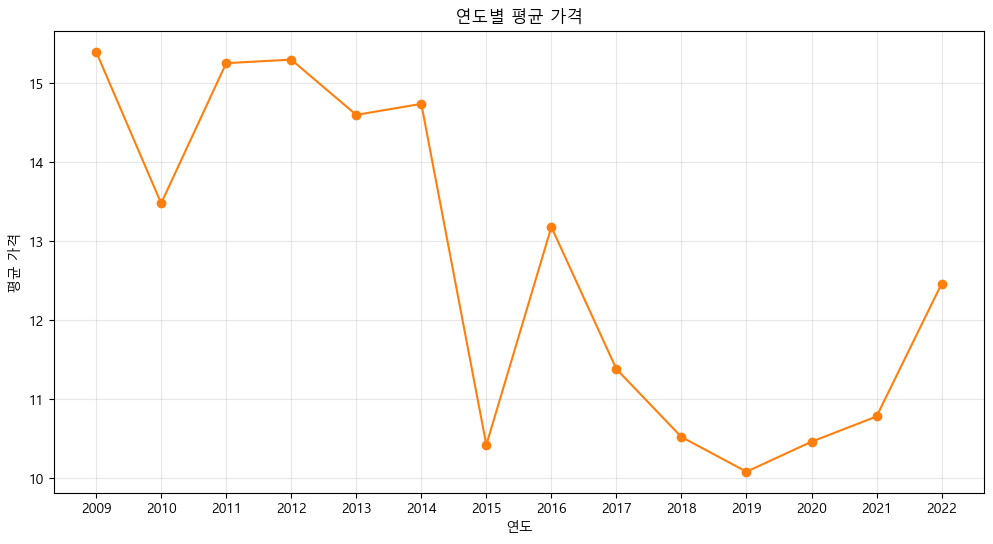

In [ ]:
plt.plot(yearly_trend["year"], yearly_trend["평균_가격"], marker="o", color="tab:orange")
plt.title("연도별 평균 가격")
plt.xlabel("연도")
plt.ylabel("평균 가격")
plt.xticks(yearly_trend["year"])
plt.grid(True, alpha=0.3)
plt.show()

## 3. 연도별 Fiction / Non Fiction 비율

In [ ]:
genre_count = (
    trend_df
    .groupby(["year", "genre"])
    .size()
    .reset_index(name="권수")
)

genre_ratio = genre_count.copy()
genre_ratio["비율"] = genre_ratio["권수"] / genre_ratio.groupby("year")["권수"].transform("sum")

genre_ratio_pivot = genre_ratio.pivot(index="year", columns="genre", values="비율").fillna(0)
genre_ratio_pivot

genre,Fiction,Non Fiction
year,,
2009,0.480000,0.520000
2010,0.400000,0.600000
2011,0.408163,0.591837
2012,0.420000,0.580000
2013,0.480000,0.520000
2014,0.583333,0.416667
2015,0.340000,0.660000
2016,0.380000,0.620000
2017,0.480000,0.520000


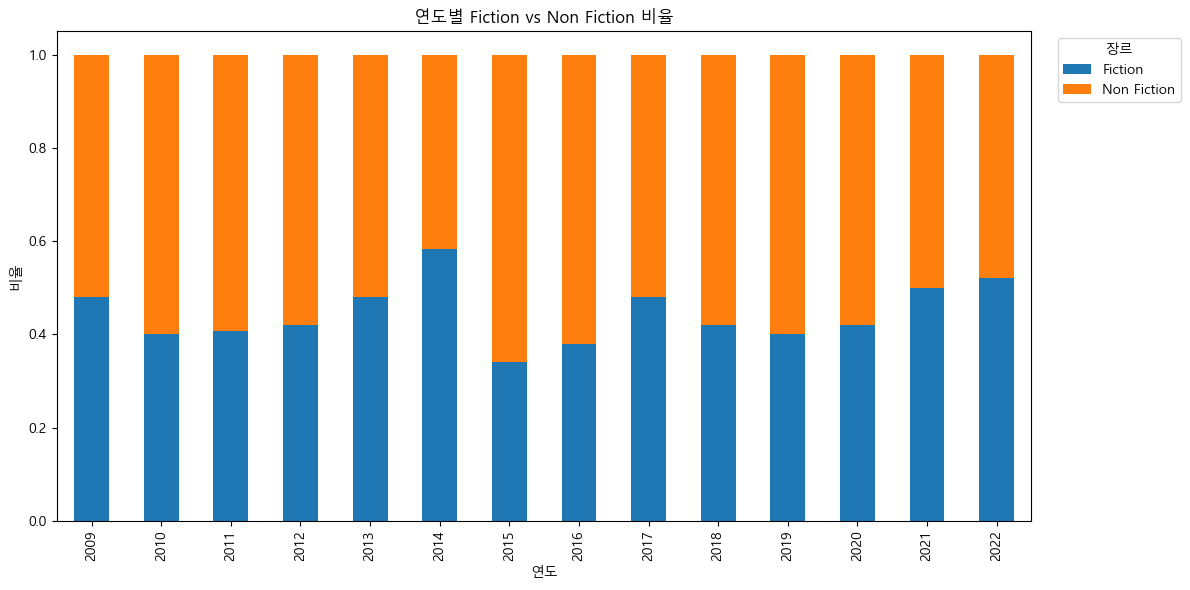

In [ ]:
genre_ratio_pivot.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("연도별 Fiction vs Non Fiction 비율")
plt.xlabel("연도")
plt.ylabel("비율")
plt.legend(title="장르", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4. 주요 지표 한눈에 비교

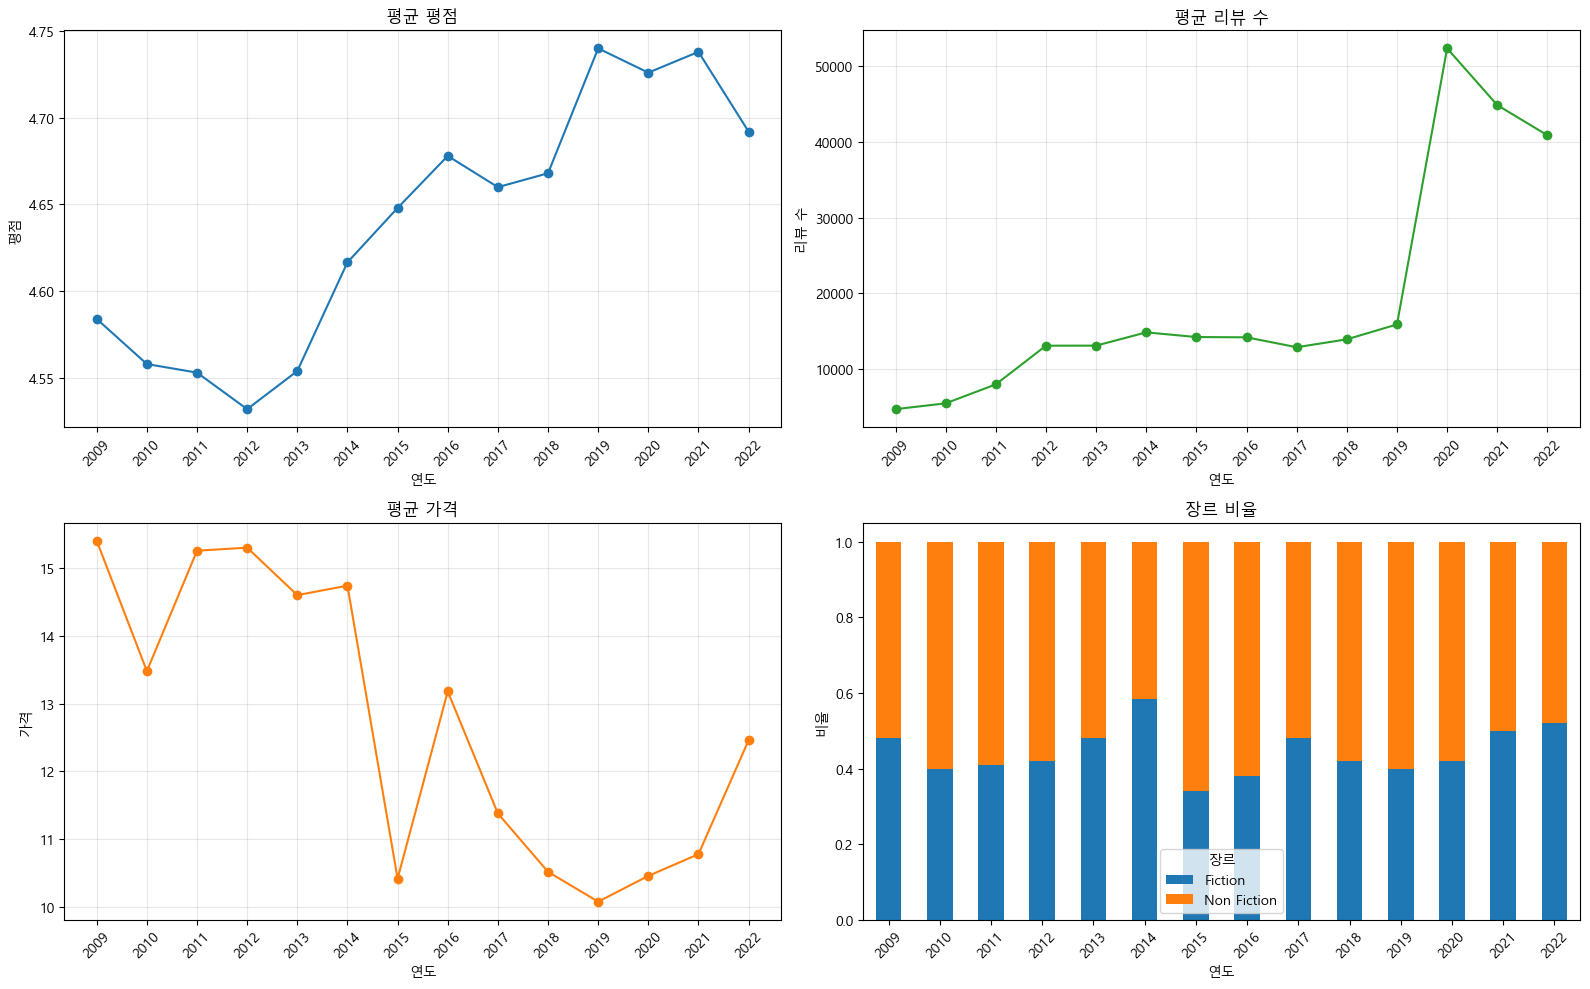

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(yearly_trend["year"], yearly_trend["평균_평점"], marker="o")
axes[0, 0].set_title("평균 평점")
axes[0, 0].set_xlabel("연도")
axes[0, 0].set_ylabel("평점")

axes[0, 1].plot(yearly_trend["year"], yearly_trend["평균_리뷰수"], marker="o", color="tab:green")
axes[0, 1].set_title("평균 리뷰 수")
axes[0, 1].set_xlabel("연도")
axes[0, 1].set_ylabel("리뷰 수")

axes[1, 0].plot(yearly_trend["year"], yearly_trend["평균_가격"], marker="o", color="tab:orange")
axes[1, 0].set_title("평균 가격")
axes[1, 0].set_xlabel("연도")
axes[1, 0].set_ylabel("가격")

genre_ratio_pivot.plot(kind="bar", stacked=True, ax=axes[1, 1])
axes[1, 1].set_title("장르 비율")
axes[1, 1].set_xlabel("연도")
axes[1, 1].set_ylabel("비율")
axes[1, 1].legend(title="장르")

for ax in axes.flat[:3]:
    ax.set_xticks(yearly_trend["year"])
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)

axes[1, 1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 5. 분석 결과 요약용 표

In [ ]:
summary = {
    "평균_평점_최고_연도": yearly_trend.loc[yearly_trend["평균_평점"].idxmax(), "year"],
    "평균_평점_최저_연도": yearly_trend.loc[yearly_trend["평균_평점"].idxmin(), "year"],
    "평균_리뷰수_최고_연도": yearly_trend.loc[yearly_trend["평균_리뷰수"].idxmax(), "year"],
    "평균_리뷰수_최저_연도": yearly_trend.loc[yearly_trend["평균_리뷰수"].idxmin(), "year"],
    "평균_가격_최고_연도": yearly_trend.loc[yearly_trend["평균_가격"].idxmax(), "year"],
    "평균_가격_최저_연도": yearly_trend.loc[yearly_trend["평균_가격"].idxmin(), "year"],
}

summary

{'평균_평점_최고_연도': np.int64(2019),
 '평균_평점_최저_연도': np.int64(2012),
 '평균_리뷰수_최고_연도': np.int64(2020),
 '평균_리뷰수_최저_연도': np.int64(2009),
 '평균_가격_최고_연도': np.int64(2009),
 '평균_가격_최저_연도': np.int64(2019)}

In [ ]:
genre_yearly_summary = genre_ratio_pivot.copy()
genre_yearly_summary["우세_장르"] = genre_yearly_summary.idxmax(axis=1)
genre_yearly_summary["우세_비율"] = genre_yearly_summary[["Fiction", "Non Fiction"]].max(axis=1)

genre_yearly_summary

genre,Fiction,Non Fiction,우세_장르,우세_비율
year,,,,
2009,0.480000,0.520000,Non Fiction,0.520000
2010,0.400000,0.600000,Non Fiction,0.600000
2011,0.408163,0.591837,Non Fiction,0.591837
2012,0.420000,0.580000,Non Fiction,0.580000
2013,0.480000,0.520000,Non Fiction,0.520000
2014,0.583333,0.416667,Fiction,0.583333
2015,0.340000,0.660000,Non Fiction,0.660000
2016,0.380000,0.620000,Non Fiction,0.620000
2017,0.480000,0.520000,Non Fiction,0.520000
